In [3]:
import pandas as pd 

In [4]:
df_diagonal_scaling = pd.read_feather('/home/na658/multi-task2/data/processed/diagonal/df_diagonal_scaling.feather')
df_diagonal_sparse_overlap = pd.read_feather('/home/na658/multi-task2/data/processed/diagonal/df_diagonal_sparse_overlap.feather')

In [3]:
df_diagonal_scaling.head()

,split,loss,seed,load_model,one_task,linear_readout,overlap,n_train,active_dims,setup,w_scaling
0,train,9.810731e-11,0,True,True,False,yes,16,5,PT+FT,1.0
1,val,1.724715e-01,0,True,True,False,yes,16,5,PT+FT,1.0
2,train,9.755297e-11,0,True,True,False,no,16,5,PT+FT,1.0
3,val,2.005829e-01,0,True,True,False,no,16,5,PT+FT,1.0
4,train,9.973599e-11,0,True,True,False,yes,32,5,PT+FT,1.0


In [49]:
experiment_df = pd.read_csv('/home/na658/multi-task2/experiment_results/experiment_results.csv')

In [50]:
experiment_df.shape

(64, 28)

In [5]:
df_diagonal_sparse_overlap[(df_diagonal_sparse_overlap['active_dims'] == 5) & (df_diagonal_sparse_overlap['setup'] == 'PT+FT') & (df_diagonal_sparse_overlap['n_train'] == 1024)].head()

,split,loss,seed,load_model,one_task,linear_readout,overlap,n_train,active_dims,setup


In [6]:
df_diagonal_sparse_overlap.n_train.unique()

array([ 16,  32,  64, 128, 256, 512])

In [52]:
df_diagonal_scaling[df_diagonal_scaling['active_dims'] == 5]

,split,loss,seed,load_model,one_task,linear_readout,overlap,n_train,active_dims,setup,w_scaling
0,train,9.810731e-11,0,True,True,False,yes,16,5,PT+FT,1.000
1,val,1.724715e-01,0,True,True,False,yes,16,5,PT+FT,1.000
2,train,9.755297e-11,0,True,True,False,no,16,5,PT+FT,1.000
3,val,2.005829e-01,0,True,True,False,no,16,5,PT+FT,1.000
4,train,9.973599e-11,0,True,True,False,yes,32,5,PT+FT,1.000
...,...,...,...,...,...,...,...,...,...,...,...
5467,val,1.809745e-10,5,False,True,False,no,512,5,STL,0.100
5468,train,8.684042e-11,5,False,True,False,no,512,5,STL,0.010
5469,val,8.503190e-11,5,False,True,False,no,512,5,STL,0.010
5470,train,9.245077e-11,5,False,True,False,no,512,5,STL,0.001


In [53]:
experiment_df.head()

,timestamp,active_dim_1,active_dim_2,c,epochs,final_epoch,final_train_loss,final_val_loss,init_method,inp_dim,...,no_tuning,one_task,overlap,plot_ground_truth_only,save_path,save_weights,scaling,seed,threshold,w_scaling
0,2025-10-09 14:10:43,40,5,0.00001,100000,4221,9.963876e-11,1.008827,simple,1000,...,False,True,5,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,1.00
1,2025-10-09 14:10:56,40,5,0.00001,100000,1124,9.927903e-11,1.007913,simple,1000,...,False,True,5,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,1.00
2,2025-10-09 14:11:11,40,5,0.00001,100000,4221,9.963876e-11,1.008827,simple,1000,...,False,True,5,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,0.01
3,2025-10-09 14:11:28,40,5,0.00001,100000,1220,9.910057e-11,1.008182,simple,1000,...,False,True,5,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,0.01
4,2025-10-09 14:11:46,40,5,0.00001,100000,2322,9.971896e-11,1.082380,simple,1000,...,False,True,0,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,1.00


In [12]:
experiment_df.columns

Index(['timestamp', 'seed', 'active_dim_1', 'active_dim_2', 'model_scaling',
       'scaling', 'n_train1', 'n_train2', 'lr', 'threshold', 'epochs',
       'overlap', 'linear_readout', 'one_task', 'load_model', 'init_method',
       'lmda', 'c', 'final_train_loss', 'final_val_loss', 'final_epoch',
       'save_path'],
      dtype='object')

In [11]:
experiment_df[experiment_df['w_scaling'] == 1.0].head()

KeyError: 'w_scaling'

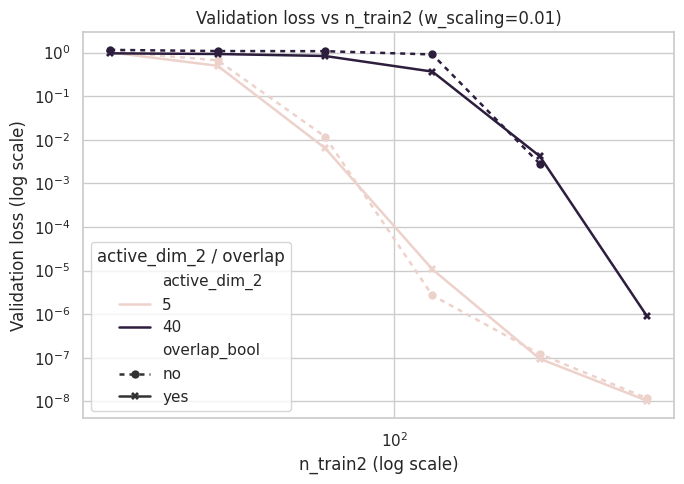

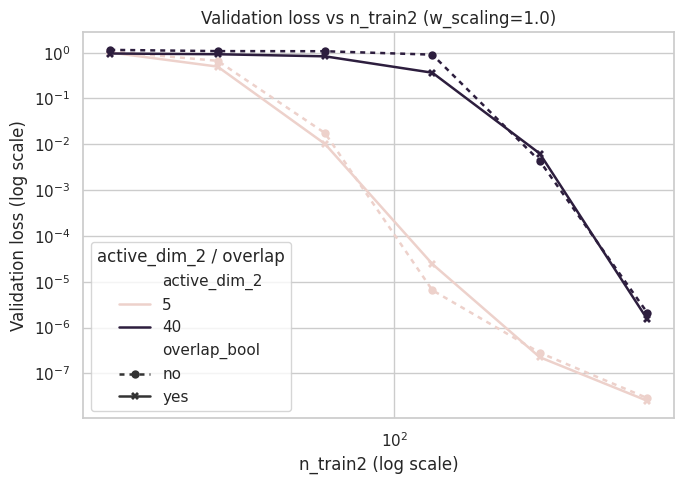

In [15]:
# Paste this cell into a Jupyter notebook cell

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
csv_path = "/home/na658/multi-task2/experiment_results/experiment_results.csv"
df = pd.read_csv(csv_path)

# Ensure numeric columns
for col in ["n_train2", "final_val_loss", "overlap", "active_dim_2", "w_scaling"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["n_train2", "final_val_loss", "overlap", "active_dim_2", "w_scaling"])

# Controls
# overlap_bool_filter: "yes", "no", or None (no filter)
overlap_bool_filter = "yes"     # change to "no" or None
active_dim2_filter = [5, 40]    # choose [5], [40], or both

# Overlap filtering per rule:
# - "no"  => overlap == 0
# - "yes" => overlap == 0 OR overlap == active_dim_2
if overlap_bool_filter == "no":
    mask_overlap = (df["overlap"] == 0)
elif overlap_bool_filter == "yes":
    mask_overlap = (df["overlap"] == 0) | (df["overlap"] == df["active_dim_2"])
else:
    mask_overlap = pd.Series(True, index=df.index)

mask_ad2 = df["active_dim_2"].isin(active_dim2_filter) if active_dim2_filter else pd.Series(True, index=df.index)
plot_df = df[mask_overlap & mask_ad2].copy()

# Boolean overlap label: 0 -> "no", else "yes"
plot_df["overlap_bool"] = np.where(plot_df["overlap"] == 0, "no", "yes")

# Safety for log axes
plot_df = plot_df[(plot_df["n_train2"] > 0) & (plot_df["final_val_loss"] > 0)]

# Aggregate duplicates (median across runs)
agg_df = (
    plot_df
    .groupby(["w_scaling", "n_train2", "active_dim_2", "overlap_bool"], as_index=False)["final_val_loss"]
    .median()
)

# Plot one figure per w_scaling
sns.set(style="whitegrid")
unique_ws = sorted(agg_df["w_scaling"].unique())

for w in unique_ws:
    df_w = agg_df[agg_df["w_scaling"] == w].sort_values("n_train2")

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.lineplot(
        data=df_w,
        x="n_train2",
        y="final_val_loss",
        hue="active_dim_2",            # color by active_dim_2 (e.g., 5 vs 40)
        style="overlap_bool",          # linestyle by overlap yes/no
        markers={"no": "o", "yes": "X"},
        dashes={"no": (2, 2), "yes": ""},
        linewidth=1.8,
        markeredgewidth=0.0,
        ax=ax,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("n_train2 (log scale)")
    ax.set_ylabel("Validation loss (log scale)")
    ax.set_title(f"Validation loss vs n_train2 (w_scaling={w})")
    ax.legend(title="active_dim_2 / overlap")

    plt.tight_layout()
    plt.show()